In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [8]:
df_basic = pd.read_csv("../data/cleaned_gigs_basic.csv")

In [9]:
df_basic.shape

(5579, 20)

In [10]:
X_basic = df_basic[[
    "rating_score",
    "rating_counts",
    "seller_level",
    "basic_delivery_days",
    "basic_revision",
    "basic_revision_unlimited"
]]

In [11]:
y_basic = df_basic["basic_price"]

In [12]:
X_train_basic, X_test_basic, y_train_basic, y_test_basic = train_test_split(
    X_basic, y_basic, test_size=0.2, random_state=0
)

In [13]:
numeric_features_basic = [
    "rating_score",
    "rating_counts",
    "seller_level",
    "basic_delivery_days",
    "basic_revision",
    "basic_revision_unlimited"
]

In [14]:
preprocessor_basic = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [15]:
X_train_transformed_basic = preprocessor_basic.fit_transform(X_train_basic)
X_test_transformed_basic = preprocessor_basic.transform(X_test_basic)

In [16]:
X_test_transformed_basic.shape

(1116, 6)

In [17]:
linear_basic = LinearRegression()

In [18]:
linear_basic.fit(X_train_transformed_basic, y_train_basic)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-7.06,-3.56,13.75,12.27, 0.17,-5.42]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,85.62
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[86.46,72.67,66.38,64.65,61.2 ,41.11]"


In [15]:
linear_basic_pred = linear_basic.predict(X_test_transformed_basic)

In [20]:
linear_basic_mae = mean_absolute_error(y_test_basic, linear_basic_pred)
linear_basic_mae

48.52897943145344

In [21]:
linear_basic_rmse = mean_squared_error(y_test_basic, linear_basic_pred) ** 0.5
linear_basic_rmse

60.205550619944354

In [22]:
linear_basic_r2 = r2_score(y_test_basic, linear_basic_pred)
linear_basic_r2

0.06661754889894189

In [23]:
ridge_basic = Ridge()

In [24]:
ridge_basic.fit(X_train_transformed_basic, y_train_basic)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [25]:
ridge_basic_pred = ridge_basic.predict(X_test_transformed_basic)

In [26]:
ridge_basic_mae = mean_absolute_error(y_test_basic, ridge_basic_pred)
ridge_basic_mae

48.529414304942705

In [27]:
ridge_basic_rmse = mean_squared_error(y_test_basic, ridge_basic_pred) ** 0.5
ridge_basic_rmse

60.20540046609

In [28]:
ridge_basic_r2 = r2_score(y_test_basic, ridge_basic_pred)
ridge_basic_r2

0.06662220464235469

In [29]:
lasso_basic = Lasso()

In [30]:
lasso_basic.fit(X_train_transformed_basic, y_train_basic)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [31]:
lasso_basic_pred = lasso_basic.predict(X_test_transformed_basic)

In [32]:
lasso_basic_mae = mean_absolute_error(y_test_basic, lasso_basic_pred)
lasso_basic_mae

48.70847517208518

In [33]:
lasso_basic_rmse = mean_squared_error(y_test_basic, lasso_basic_pred) ** 0.5
lasso_basic_rmse

60.17701891315976

In [34]:
lasso_basic_r2 = r2_score(y_test_basic, lasso_basic_pred)
lasso_basic_r2

0.06750200835023401

In [35]:
elastic_net_basic = ElasticNet()

In [36]:
elastic_net_basic.fit(X_train_transformed_basic, y_train_basic)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [37]:
elastic_net_basic_pred = elastic_net_basic.predict(X_test_transformed_basic)

In [38]:
elastic_net_basic_mae = mean_absolute_error(y_test_basic, elastic_net_basic_pred)
elastic_net_basic_mae

49.31285159860164

In [39]:
elastic_net_basic_rmse = mean_squared_error(y_test_basic, elastic_net_basic_pred) ** 0.5
elastic_net_basic_rmse

60.46258107192286

In [40]:
elastic_net_basic_r2 = r2_score(y_test_basic, elastic_net_basic_pred)
elastic_net_basic_r2

0.05863091578528301

In [41]:
random_forest_basic = RandomForestRegressor(n_estimators=100,random_state=42,max_depth=10,min_samples_split=5,min_samples_leaf=2,)

In [42]:
random_forest_basic.fit(X_train_transformed_basic, y_train_basic)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [43]:
random_forest_basic_pred = random_forest_basic.predict(X_test_transformed_basic)

In [44]:
random_forest_basic_mae = mean_absolute_error(y_test_basic, random_forest_basic_pred)
random_forest_basic_mae

45.23045392342791

In [45]:
random_forest_basic_rmse = mean_squared_error(y_test_basic, random_forest_basic_pred) ** 0.5
random_forest_basic_rmse

57.94605703871736

In [46]:
random_forest_basic_r2 = r2_score(y_test_basic, random_forest_basic_pred)
random_forest_basic_r2

0.13536194690814718

In [47]:
results_basic = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Elastic Net",
        "Random Forest"
    ],
    "MAE": [
        linear_basic_mae,
        ridge_basic_mae,
        lasso_basic_mae,
        elastic_net_basic_mae,
        random_forest_basic_mae
    ],
    "RMSE": [
        linear_basic_rmse,
        ridge_basic_rmse,
        lasso_basic_rmse,
        elastic_net_basic_rmse,
        random_forest_basic_rmse
    ],
    "R2": [
        linear_basic_r2,
        ridge_basic_r2,
        lasso_basic_r2,
        elastic_net_basic_r2,
        random_forest_basic_r2
    ]
})

results_basic

,Model,MAE,RMSE,R2
0,Linear Regression,48.528979,60.205551,0.066618
1,Ridge,48.529414,60.205400,0.066622
2,Lasso,48.708475,60.177019,0.067502
3,Elastic Net,49.312852,60.462581,0.058631
4,Random Forest,45.230454,57.946057,0.135362


In [48]:
results_basic.sort_values("MAE")

,Model,MAE,RMSE,R2
4,Random Forest,45.230454,57.946057,0.135362
0,Linear Regression,48.528979,60.205551,0.066618
1,Ridge,48.529414,60.205400,0.066622
2,Lasso,48.708475,60.177019,0.067502
3,Elastic Net,49.312852,60.462581,0.058631


In [49]:
linear_basic_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_basic),
    ("model", linear_basic)
])


In [50]:
ridge_basic_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_basic),
    ("model", ridge_basic)
])


In [51]:
lasso_basic_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_basic),
    ("model", lasso_basic)
])


In [52]:
elastic_net_basic_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_basic),
    ("model", elastic_net_basic)
])


In [53]:
random_forest_basic_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_basic),
    ("model", random_forest_basic)
])


In [54]:
linear_basic_cv = -cross_val_score(linear_basic_cv_pipeline, X_basic, y_basic, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()
ridge_basic_cv = -cross_val_score(ridge_basic_cv_pipeline, X_basic, y_basic, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()
lasso_basic_cv = -cross_val_score(lasso_basic_cv_pipeline, X_basic, y_basic, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()
elastic_net_basic_cv = -cross_val_score(elastic_net_basic_cv_pipeline, X_basic, y_basic, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()
random_forest_basic_cv = -cross_val_score(random_forest_basic_cv_pipeline, X_basic, y_basic, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()


In [55]:
cv_results_basic = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Elastic Net",
        "Random Forest"
    ],
    "CV MAE": [
        linear_basic_cv,
        ridge_basic_cv,
        lasso_basic_cv,
        elastic_net_basic_cv,
        random_forest_basic_cv
    ]
})

cv_results_basic.sort_values("CV MAE")


,Model,CV MAE
4,Random Forest,45.663908
0,Linear Regression,48.482278
1,Ridge,48.482610
2,Lasso,48.630889
3,Elastic Net,49.182927


In [56]:
df_basic.columns

Index(['gig_title', 'rating_score', 'rating_counts', 'seller_level',
       'category', 'basic_price', 'standard_price', 'premium_price',
       'basic_delivery_days', 'standard_delivery_days',
       'premium_delivery_days', 'basic_revision', 'basic_revision_unlimited',
       'standard_revision', 'standard_revision_unlimited', 'premium_revision',
       'premium_revision_unlimited', 'basic_features', 'standard_features',
       'premium_features'],
      dtype='str')

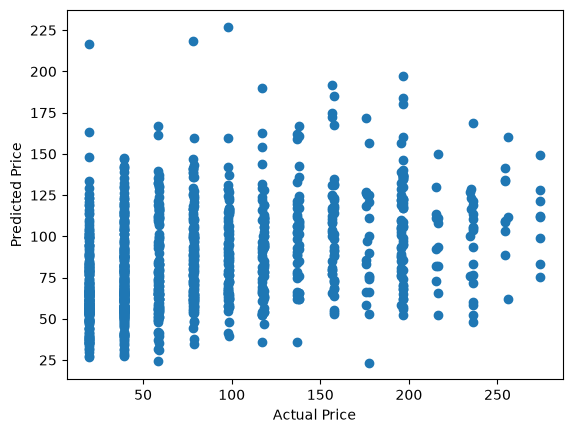

In [57]:
plt.scatter(y_test_basic, random_forest_basic_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [58]:
df_standard = pd.read_csv("../data/cleaned_gigs_standard.csv")

In [59]:
X_standard = df_standard[[
    "rating_score",
    "rating_counts",
    "seller_level",
    "standard_delivery_days",
    "standard_revision",
    "standard_revision_unlimited"
]]

In [60]:
y_standard = df_standard["standard_price"]

In [61]:
X_train_standard, X_test_standard, y_train_standard, y_test_standard = train_test_split(
    X_standard, y_standard, test_size=0.2, random_state=0
)

In [62]:
numeric_features_standard = [
    "rating_score",
    "rating_counts",
    "seller_level",
    "standard_delivery_days",
    "standard_revision",
    "standard_revision_unlimited"
]

In [63]:
preprocessor_standard = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [64]:
X_train_transformed_standard = preprocessor_standard.fit_transform(X_train_standard)
X_test_transformed_standard = preprocessor_standard.transform(X_test_standard)

In [65]:
linear_standard = LinearRegression()

In [66]:
linear_standard.fit(X_train_transformed_standard, y_train_standard)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-15.95, -8.86, 28.7 , 38.54, 1.67, -2.97]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,211.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[87.9 ,73.95,67.4 ,65.35,62.73,42.06]"


In [67]:
linear_standard_pred = linear_standard.predict(X_test_transformed_standard)

In [68]:
linear_standard_mae = mean_absolute_error(y_test_standard, linear_standard_pred)

In [69]:
linear_standard_rmse = mean_squared_error(y_test_standard, linear_standard_pred) ** 0.5
linear_standard_rmse

146.57338012191602

In [70]:
linear_standard_r2 = r2_score(y_test_standard, linear_standard_pred)
linear_standard_r2

0.08172664815520236

In [71]:
ridge_standard = Ridge()

In [72]:
ridge_standard.fit(X_train_transformed_standard, y_train_standard)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [73]:
ridge_standard_pred = ridge_standard.predict(X_test_transformed_standard)

In [74]:
ridge_standard_mae = mean_absolute_error(y_test_standard, ridge_standard_pred)
ridge_standard_mae

117.3393879772878

In [75]:
ridge_standard_rmse = mean_squared_error(y_test_standard, ridge_standard_pred) ** 0.5
ridge_standard_rmse

146.5730660982432

In [76]:
ridge_standard_r2 = r2_score(y_test_standard, ridge_standard_pred)
ridge_standard_r2

0.08173058282958101

In [77]:
lasso_standard = Lasso()

In [78]:
lasso_standard.fit(X_train_transformed_standard, y_train_standard)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [79]:
lasso_standard_pred = lasso_standard.predict(X_test_transformed_standard)

In [80]:
lasso_standard_mae = mean_absolute_error(y_test_standard, lasso_standard_pred)
lasso_standard_mae

117.42598183456153

In [81]:
lasso_standard_rmse = mean_squared_error(y_test_standard, lasso_standard_pred) ** 0.5
lasso_standard_rmse

146.5415768488997

In [82]:
lasso_standard_r2 = r2_score(y_test_standard, lasso_standard_pred)
lasso_standard_r2

0.08212509608288532

In [83]:
elastic_net_standard = ElasticNet()

In [84]:
elastic_net_standard.fit(X_train_transformed_standard, y_train_standard)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [85]:
elastic_net_standard_pred = elastic_net_standard.predict(X_test_transformed_standard)

In [86]:
elastic_net_standard_mae = mean_absolute_error(y_test_standard, elastic_net_standard_pred)
elastic_net_standard_mae

119.25506674956048

In [87]:
elastic_net_standard_rmse = mean_squared_error(y_test_standard, elastic_net_standard_pred) ** 0.5
elastic_net_standard_rmse

147.3398085423526

In [88]:
elastic_net_standard_r2 = r2_score(y_test_standard, elastic_net_standard_pred)
elastic_net_standard_r2

0.07209828527043072

In [89]:
random_forest_standard = RandomForestRegressor(n_estimators=100,random_state=42,max_depth=10,min_samples_split=5,min_samples_leaf=2,)

In [90]:
random_forest_standard.fit(X_train_transformed_standard, y_train_standard)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [91]:
random_forest_standard_pred = random_forest_standard.predict(X_test_transformed_standard)

In [92]:
random_forest_standard_mae = mean_absolute_error(y_test_standard, random_forest_standard_pred)
random_forest_standard_mae

106.91450155580638

In [93]:
random_forest_standard_rmse = mean_squared_error(y_test_standard, random_forest_standard_pred) ** 0.5
random_forest_standard_rmse

136.31682846258508

In [94]:
random_forest_standard_r2 = r2_score(y_test_standard, random_forest_standard_pred)
random_forest_standard_r2

0.20574360278927106

In [95]:
results_standard = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "Elastic Net", "Random Forest"],
    "MAE": [linear_standard_mae, ridge_standard_mae, lasso_standard_mae, elastic_net_standard_mae, random_forest_standard_mae],
    "RMSE": [linear_standard_rmse, ridge_standard_rmse, lasso_standard_rmse, elastic_net_standard_rmse, random_forest_standard_rmse],
    "R2": [linear_standard_r2, ridge_standard_r2, lasso_standard_r2, elastic_net_standard_r2, random_forest_standard_r2]
})

results_standard.sort_values("MAE")

,Model,MAE,RMSE,R2
4,Random Forest,106.914502,136.316828,0.205744
0,Linear Regression,117.338702,146.573380,0.081727
1,Ridge,117.339388,146.573066,0.081731
2,Lasso,117.425982,146.541577,0.082125
3,Elastic Net,119.255067,147.339809,0.072098


In [96]:
linear_standard_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_standard),
    ("model", linear_standard)
])


In [97]:
ridge_standard_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_standard),
    ("model", ridge_standard)
])


In [98]:
lasso_standard_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_standard),
    ("model", lasso_standard)
])


In [99]:
elastic_net_standard_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_standard),
    ("model", elastic_net_standard)
])


In [100]:
random_forest_standard_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_standard),
    ("model", random_forest_standard)
])


In [101]:
linear_standard_cv = -cross_val_score(linear_standard_cv_pipeline, X_standard, y_standard, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()
ridge_standard_cv = -cross_val_score(ridge_standard_cv_pipeline, X_standard, y_standard, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()
lasso_standard_cv = -cross_val_score(lasso_standard_cv_pipeline, X_standard, y_standard, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()
elastic_net_standard_cv = -cross_val_score(elastic_net_standard_cv_pipeline, X_standard, y_standard, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()
random_forest_standard_cv = -cross_val_score(random_forest_standard_cv_pipeline, X_standard, y_standard, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()


In [102]:
cv_results_standard = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Elastic Net",
        "Random Forest"
    ],
    "CV MAE": [
        linear_standard_cv,
        ridge_standard_cv,
        lasso_standard_cv,
        elastic_net_standard_cv,
        random_forest_standard_cv
    ]
})

cv_results_standard.sort_values("CV MAE")


,Model,CV MAE
4,Random Forest,104.099593
0,Linear Regression,113.773898
1,Ridge,113.774883
2,Lasso,113.933286
3,Elastic Net,115.828580


In [103]:
df_premium = pd.read_csv("../data/cleaned_gigs_premium.csv")

In [104]:
X_premium = df_premium[[
    "rating_score",
    "rating_counts",
    "seller_level",
    "premium_delivery_days",
    "premium_revision",
    "premium_revision_unlimited"
]]

In [105]:
y_premium = df_premium["premium_price"]

In [106]:
X_premium_train, X_premium_test, y_premium_train, y_premium_test = train_test_split(
    X_premium, y_premium, test_size=0.2, random_state=0
)

In [107]:
numeric_features_premium = [
    "rating_score",
    "rating_counts",
    "seller_level",
    "premium_delivery_days",
    "premium_revision",
    "premium_revision_unlimited"
]

In [108]:
preprocessor_premium = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [109]:
X_train_transformed_premium = preprocessor_premium.fit_transform(X_premium_train)
X_test_transformed_premium = preprocessor_premium.transform(X_premium_test)

In [110]:
linear_premium = LinearRegression()

In [111]:
linear_premium.fit(X_train_transformed_premium, y_premium_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-21.51,-20.86, 50.31, 78.61, 0.9 , -2.63]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,368.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[88.32,74.1 ,66.43,64.09,62.47,41.8 ]"


In [112]:
linear_premium_pred = linear_premium.predict(X_test_transformed_premium)

In [113]:
linear_premium_mae = mean_absolute_error(y_premium_test, linear_premium_pred)
linear_premium_mae

201.34745775663404

In [114]:
linear_premium_rmse = mean_squared_error(y_premium_test, linear_premium_pred) ** 0.5
linear_premium_rmse

258.26480586997474

In [115]:
linear_premium_r2 = r2_score(y_premium_test, linear_premium_pred)
linear_premium_r2

0.056952276355036635

In [116]:
ridge_premium = Ridge()

In [117]:
ridge_premium.fit(X_train_transformed_premium, y_premium_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [118]:
ridge_premium_pred = ridge_premium.predict(X_test_transformed_premium)

In [119]:
ridge_premium_mae = mean_absolute_error(y_premium_test, ridge_premium_pred)
ridge_premium_mae

201.34802163677017

In [120]:
ridge_premium_rmse = mean_squared_error(y_premium_test, ridge_premium_pred) ** 0.5
ridge_premium_rmse

258.2621254500116

In [121]:
ridge_premium_r2 = r2_score(y_premium_test, ridge_premium_pred)
ridge_premium_r2

0.05697185123144188

In [122]:
lasso_premium = Lasso()

In [123]:
lasso_premium.fit(X_train_transformed_premium, y_premium_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [124]:
lasso_premium_pred = lasso_premium.predict(X_test_transformed_premium)

In [125]:
lasso_premium_mae = mean_absolute_error(y_premium_test, lasso_premium_pred)
lasso_premium_mae

201.4051150804145

In [126]:
lasso_premium_rmse = mean_squared_error(y_premium_test, lasso_premium_pred) ** 0.5
lasso_premium_rmse

258.02792797632486

In [127]:
lasso_premium_r2 = r2_score(y_premium_test, lasso_premium_pred)
lasso_premium_r2

0.058681390884628315

In [128]:
elastic_net_premium = ElasticNet()

In [129]:
elastic_net_premium.fit(X_train_transformed_premium, y_premium_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [130]:
elastic_net_premium_pred = elastic_net_premium.predict(X_test_transformed_premium)

In [131]:
elastic_net_premium_mae = mean_absolute_error(y_premium_test, elastic_net_premium_pred)
elastic_net_premium_mae

204.0553165834264

In [132]:
elastic_net_premium_rmse = mean_squared_error(y_premium_test, elastic_net_premium_pred) ** 0.5
elastic_net_premium_rmse

257.0520943813943

In [133]:
elastic_net_premium_r2 = r2_score(y_premium_test, elastic_net_premium_pred)
elastic_net_premium_r2

0.06578785693975453

In [134]:
random_forest_premium = RandomForestRegressor(n_estimators=100,random_state=42,max_depth=10,min_samples_split=5,min_samples_leaf=2,)

In [135]:
random_forest_premium.fit(X_train_transformed_premium, y_premium_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [136]:
random_forest_premium_pred = random_forest_premium.predict(X_test_transformed_premium)

In [137]:
random_forest_premium_mae = mean_absolute_error(y_premium_test, random_forest_premium_pred)
random_forest_premium_mae

181.83398199420827

In [138]:
random_forest_premium_rmse = mean_squared_error(y_premium_test, random_forest_premium_pred) ** 0.5
random_forest_premium_rmse

237.51435972809813

In [139]:
random_forest_premium_r2 = r2_score(y_premium_test, random_forest_premium_pred)
random_forest_premium_r2

0.2024040178572345

In [140]:
results_premium = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "Elastic Net", "Random Forest"],
    "MAE": [linear_premium_mae, ridge_premium_mae, lasso_premium_mae, elastic_net_premium_mae, random_forest_premium_mae],
    "RMSE": [linear_premium_rmse, ridge_premium_rmse, lasso_premium_rmse, elastic_net_premium_rmse, random_forest_premium_rmse],
    "R2": [linear_premium_r2, ridge_premium_r2, lasso_premium_r2, elastic_net_premium_r2, random_forest_premium_r2]
})

results_premium.sort_values("MAE")

,Model,MAE,RMSE,R2
4,Random Forest,181.833982,237.514360,0.202404
0,Linear Regression,201.347458,258.264806,0.056952
1,Ridge,201.348022,258.262125,0.056972
2,Lasso,201.405115,258.027928,0.058681
3,Elastic Net,204.055317,257.052094,0.065788


In [141]:
linear_premium_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_premium),
    ("model", linear_premium)
])


In [142]:
ridge_premium_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_premium),
    ("model", ridge_premium)
])


In [143]:
lasso_premium_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_premium),
    ("model", lasso_premium)
])


In [144]:
elastic_net_premium_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_premium),
    ("model", elastic_net_premium)
])


In [145]:
random_forest_premium_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor_premium),
    ("model", random_forest_premium)
])


In [146]:
linear_premium_cv = -cross_val_score(linear_premium_cv_pipeline, X_premium, y_premium, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()
ridge_premium_cv = -cross_val_score(ridge_premium_cv_pipeline, X_premium, y_premium, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()
lasso_premium_cv = -cross_val_score(lasso_premium_cv_pipeline, X_premium, y_premium, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()
elastic_net_premium_cv = -cross_val_score(elastic_net_premium_cv_pipeline, X_premium, y_premium, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()
random_forest_premium_cv = -cross_val_score(random_forest_premium_cv_pipeline, X_premium, y_premium, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1).mean()


In [147]:
cv_results_premium = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Elastic Net",
        "Random Forest"
    ],
    "CV MAE": [
        linear_premium_cv,
        ridge_premium_cv,
        lasso_premium_cv,
        elastic_net_premium_cv,
        random_forest_premium_cv
    ]
})

cv_results_premium.sort_values("CV MAE")


,Model,CV MAE
4,Random Forest,181.106138
0,Linear Regression,196.897042
1,Ridge,196.898701
2,Lasso,197.032195
3,Elastic Net,200.482640


In [148]:
best_basic_model = Pipeline([
    ("preprocessor", preprocessor_basic),
    ("model", random_forest_basic)
])

In [149]:
best_basic_model.fit(X_train_basic, y_train_basic)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['rating_score','rating_counts','seller_level','basic_delivery_days', 'basic_revision','basic_revision_unlimited']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers

In [150]:
best_standard_model = Pipeline([
    ("preprocessor", preprocessor_standard),
    ("model", random_forest_standard)
])

In [151]:
best_standard_model.fit(X_train_standard, y_train_standard)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['rating_score','rating_counts','seller_level','standard_delivery_days', 'standard_revision','standard_revision_unlimited']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetra

In [152]:
best_premium_model = Pipeline([
    ("preprocessor", preprocessor_premium),
    ("model", random_forest_premium)
])

In [153]:
best_premium_model.fit(X_premium_train, y_premium_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['rating_score','rating_counts','seller_level','premium_delivery_days', 'premium_revision','premium_revision_unlimited']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransf

In [154]:
joblib.dump(best_basic_model, "../models/best_basic_model.pkl")

['../models/best_basic_model.pkl']

In [155]:
joblib.dump(best_standard_model, "../models/best_standard_model.pkl")

['../models/best_standard_model.pkl']

In [156]:
joblib.dump(best_premium_model, "../models/best_premium_model.pkl")

['../models/best_premium_model.pkl']